In [ ]:
# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


# Configure sklearn to preserve feature names through pipelines
set_config(transform_output="pandas")

# define random seed for reproducibility
RANDOM_SEED = 42

# Load dataset
df = pd.read_csv('../data/raw/bank-additional/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [35]:
# Separate features and target
X = df.drop(['y'], axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Stratified split ensures the target class ratio is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, 
    # with stratification to maintain class balance in train/test sets becauese the target variable is imbalanced 
    stratify=y, 
)

# print out the target class distribution in the original dataset, training set, 
# and test set to verify stratification
class_dist_df = pd.DataFrame({
    'Dataset': ['Original', 'Training', 'Test'],
    'Class 0 (No)': [
        y.value_counts(normalize=True)[0],
        y_train.value_counts(normalize=True)[0],
        y_test.value_counts(normalize=True)[0]
    ],
    'Class 1 (Yes)': [
        y.value_counts(normalize=True)[1],
        y_train.value_counts(normalize=True)[1],
        y_test.value_counts(normalize=True)[1]
    ]
})

print("\n" + "="*60)
print("Class Distribution Comparison Table:")
print("="*60)
print(class_dist_df.to_string(index=False))
print("="*60)


Class Distribution Comparison Table:
 Dataset  Class 0 (No)  Class 1 (Yes)
Original      0.887346       0.112654
Training      0.887344       0.112656
    Test      0.887351       0.112649


Stratification ensures the test set accurately represents the real-world class distribution. Without it, our test set might have significantly fewer positive cases (subscriptions), making performance metrics unreliable. This consistency is critical for imbalanced datasets — it prevents overly optimistic accuracy scores that hide poor minority class performance.

In [ ]:
# Define feature groups
num_cols = ['age', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'housing', 'loan']

In [36]:
# Define column transformer for preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    # request dense output from one-hot encoder to avoid SHAP sparse dtype errors
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [ ]:
# Create baseline pipline by using LogisticRegression as a simple model
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

simple_model_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED))
])

simple_model_pipeline

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given s

In [18]:
simple_model_pipeline.fit(X_train, y_train)
simple_model_score = simple_model_pipeline.score(X_test, y_test)
print(f"Baseline Logistic Regression Accuracy: {simple_model_score:.4f}")

Baseline Logistic Regression Accuracy: 0.7429


In [19]:
# Pipeline: Preprocess -> Feature Selection -> Classifier
model_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.7, random_state=RANDOM_SEED)),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced_subsample',
        random_state=RANDOM_SEED))])

model_pipeline

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given s

In [20]:
model_pipeline.fit(X_train, y_train)      # ensure pipeline is trained

model_pipleline_score = model_pipeline.score(X_test, y_test)
print(f"Random Forest Accuracy: {model_pipleline_score:.4f}")

Random Forest Accuracy: 0.8449


In [32]:
# Create another pipeline with using LightGBM as the classifier (simpler than XGBoost on macOS)
from lightgbm import LGBMClassifier
lgb_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.88, random_state=RANDOM_SEED)),
    ('clf', LGBMClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        scale_pos_weight=0.7,
        random_state=RANDOM_SEED,
        verbose=-1))])
lgb_pipeline.fit(X_train, y_train)
y_pred_lgb = lgb_pipeline.predict(X_test)
f1_lgb = f1_score(y_test, y_pred_lgb)
print(f"LightGBM F1-score: {f1_lgb:.4f}")

LightGBM F1-score: 0.3369


/Users/alstonwong/DSI_C8/Team_ML10/ml10-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7310
           1       0.33      0.36      0.35       928

    accuracy                           0.84      8238
   macro avg       0.62      0.64      0.63      8238
weighted avg       0.85      0.84      0.85      8238



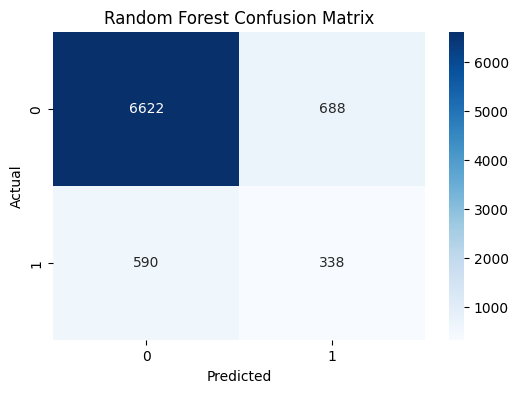

In [23]:

# Save the trained pipeline for later use
#joblib.dump(model_pipeline, '../models/bank_rf_pipeline.joblib')

# KPIs to evaluate on test set, not training set, to get an unbiased estimate of performance
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model_pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
# Plot the confustion matrix for 3 modals as a heatmap for better visualization using seaborn 
import seaborn as sns

# layout 1 row, 3 columns


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 






In [24]:
# Print feature importances from the random forest
feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()
importances = model_pipeline.named_steps['clf'].feature_importances_
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Feature Importances:")
print(feature_importances)

Feature Importances:
num__campaign                         0.203779
num__pdays                            0.169398
num__age                              0.147801
num__previous                         0.072826
cat__job_blue-collar                  0.037463
cat__education_university.degree      0.031138
cat__job_admin.                       0.025906
cat__marital_single                   0.025605
cat__job_retired                      0.024302
cat__marital_married                  0.022660
cat__education_basic.9y               0.022303
cat__job_student                      0.021106
cat__marital_divorced                 0.018624
cat__education_high.school            0.015814
cat__education_basic.4y               0.015031
cat__job_services                     0.013755
cat__loan_yes                         0.013618
cat__job_technician                   0.013427
cat__loan_no                          0.013414
cat__housing_yes                      0.012074
cat__housing_no                       0

/Users/alstonwong/DSI_C8/Team_ML10/ml10-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


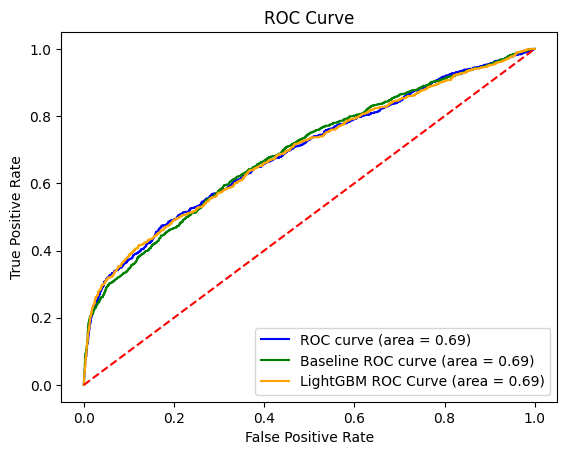

In [28]:
# Plot Random Fores and the baseline logistic regression AUC-ROC curve for comparison
from sklearn.metrics import roc_curve, auc
y_prob = model_pipeline.predict_proba(X_test)[:, 1]  # get probabilities
y_prob_baseline = simple_model_pipeline.predict_proba(X_test)[:, 1]
y_prob_lgb = lgb_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
fpr_baseline, tpr_baseline, thresholds_baseline = roc_curve(y_test, y_prob_baseline)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot(fpr_baseline, tpr_baseline, color='green', label=f'Baseline ROC curve (area = {roc_auc_baseline:.2f})')
plt.plot(fpr_lgb, tpr_lgb, color='orange', label=f'LightGBM ROC Curve (area = {roc_auc_lgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()  

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.742899   0.218277 0.496767  0.303289
      Random Forest  0.844865   0.329435 0.364224  0.345957
           LightGBM  0.895849   0.595628 0.234914  0.336940


/Users/alstonwong/DSI_C8/Team_ML10/ml10-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


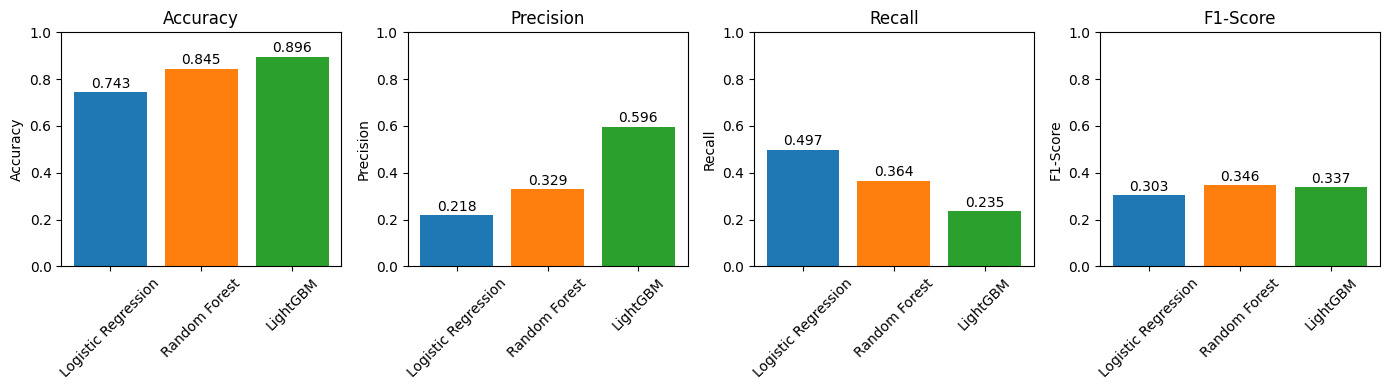

In [31]:
# Compare the accuracies of the models
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get predictions from all models
y_pred_rf = model_pipeline.predict(X_test)
y_pred_baseline = simple_model_pipeline.predict(X_test)
y_pred_lgb = lgb_pipeline.predict(X_test)

# Calculate metrics for all models
models = ['Logistic Regression', 'Random Forest', 'LightGBM']
accuracies = [
    accuracy_score(y_test, y_pred_baseline),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lgb)
]
precisions = [
    precision_score(y_test, y_pred_baseline),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_lgb)
]
recalls = [
    recall_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_lgb)
]
f1_scores = [
    f1_score(y_test, y_pred_baseline),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_lgb)
]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize the comparison
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    axes[idx].bar(models, comparison_df[metric], color=colors)
    axes[idx].set_ylabel(metric)
    axes[idx].set_ylim([0, 1])
    axes[idx].set_title(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [30]:
print("Class distribution in training data:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test data:")
print(y_test.value_counts(normalize=True))

Class distribution in training data:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Class distribution in test data:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64
